In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [7]:
data = fetch_ucirepo(id=183)

X = data.data.features
y = data.data.targets

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1994, 127)
y shape: (1994, 1)


In [8]:
X.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,?,0.02,0.12,0.45,?,?,?,?,0.00,?
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,?,0.01,0.21,0.02,?,?,?,?,0.00,?
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,?,0.02,0.39,0.28,?,?,?,?,0.00,?
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,?,0.04,0.09,0.02,?,?,?,?,0.00,?


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 127 entries, state to PolicBudgPerPop
dtypes: float64(99), int64(2), object(26)
memory usage: 1.9+ MB


In [10]:
y.head()

,ViolentCrimesPerPop
0,0.20
1,0.67
2,0.43
3,0.12
4,0.03


In [11]:
X.select_dtypes(include="object").columns

Index(['county', 'community', 'communityname', 'OtherPerCap', 'LemasSwornFT',
       'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop',
       'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
       'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
       'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
       'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg',
       'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'PolicBudgPerPop'],
      dtype='object')

In [12]:
# Replace '?' with missing values
X = X.replace("?", np.nan)

# Remove non-predictive columns
drop_cols = ["state", "county", "community", "communityname", "fold"]
X = X.drop(columns=drop_cols, errors="ignore")

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Convert target to numeric
y = y.apply(pd.to_numeric, errors="coerce").squeeze()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Median imputation, fitted ONLY on training data
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Missing values in train:", X_train.isna().sum().sum())
print("Missing values in test:", X_test.isna().sum().sum())

Training set: (1595, 122)
Testing set: (399, 122)
Missing values in train: 0
Missing values in test: 0


In [13]:
from sklearn.preprocessing import StandardScaler

# Feature engineering
X_train["SocioEconomicStress"] = X_train[
    ["PctUnemployed", "PctPopUnderPov", "PctNotHSGrad"]
].mean(axis=1)

X_test["SocioEconomicStress"] = X_test[
    ["PctUnemployed", "PctPopUnderPov", "PctNotHSGrad"]
].mean(axis=1)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scale training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scale training data: (1595, 123)
Scaled testing data: (399, 123)


In [14]:
print("Dataset shape:", X.shape)

print("\nData types:")
print(X.dtypes.value_counts())

print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False).head(15))

print("\nTarget statistics:")
print(y.describe())

Dataset shape: (1994, 122)

Data types:
float64    122
Name: count, dtype: int64

Missing values:
LemasSwFTFieldPerPop    1675
LemasSwFTFieldOps       1675
RacialMatchCommPol      1675
PctPolicWhite           1675
LemasSwornFT            1675
LemasSwFTPerPop         1675
LemasTotReqPerPop       1675
LemasTotalReq           1675
PolicPerPop             1675
PolicReqPerOffic        1675
PolicBudgPerPop         1675
PolicCars               1675
LemasGangUnitDeploy     1675
LemasPctPolicOnPatr     1675
PolicAveOTWorked        1675
dtype: int64

Target statistics:
count    1994.000000
mean        0.237979
std         0.232985
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: ViolentCrimesPerPop, dtype: float64


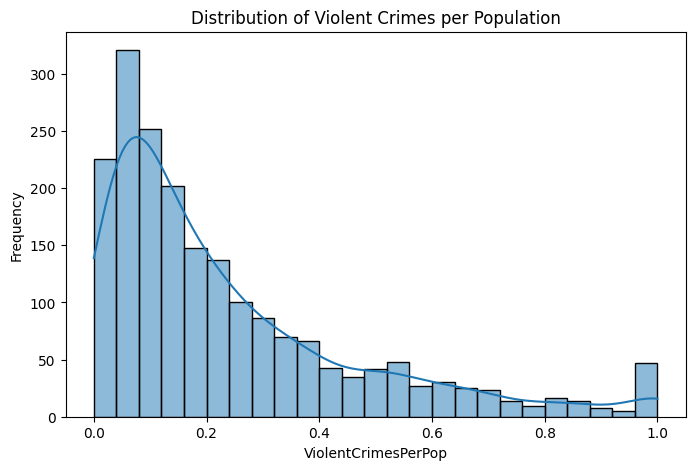

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True)
plt.title("Distribution of Violent Crimes per Population")
plt.xlabel("ViolentCrimesPerPop")
plt.ylabel("Frequency")
plt.show()

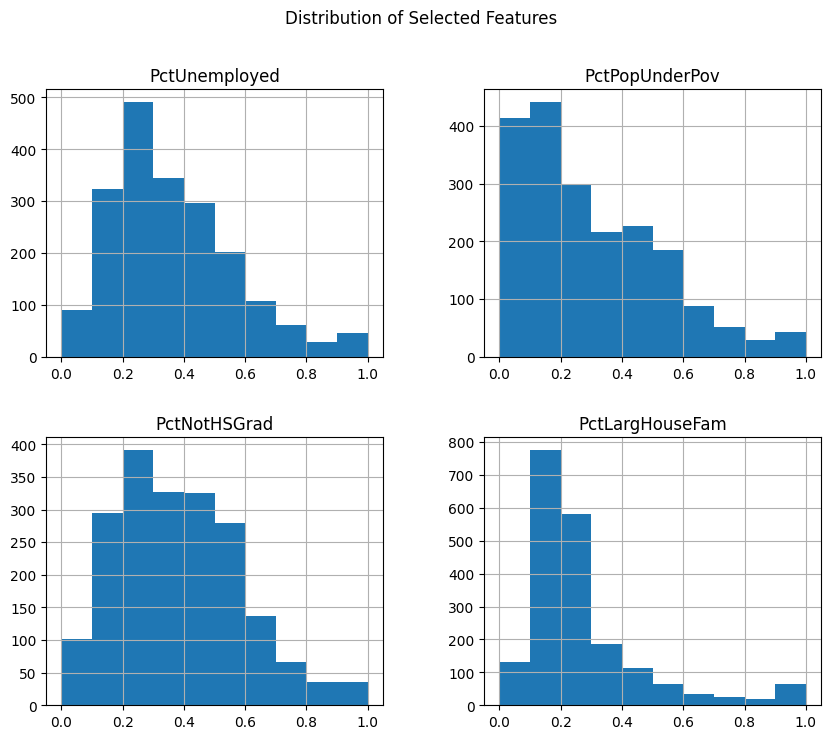

In [16]:
features_to_plot = [
    "PctUnemployed",
    "PctPopUnderPov",
    "PctNotHSGrad",
    "PctLargHouseFam"
]

X[features_to_plot].hist(figsize=(10, 8))
plt.suptitle("Distribution of Selected Features")
plt.show()

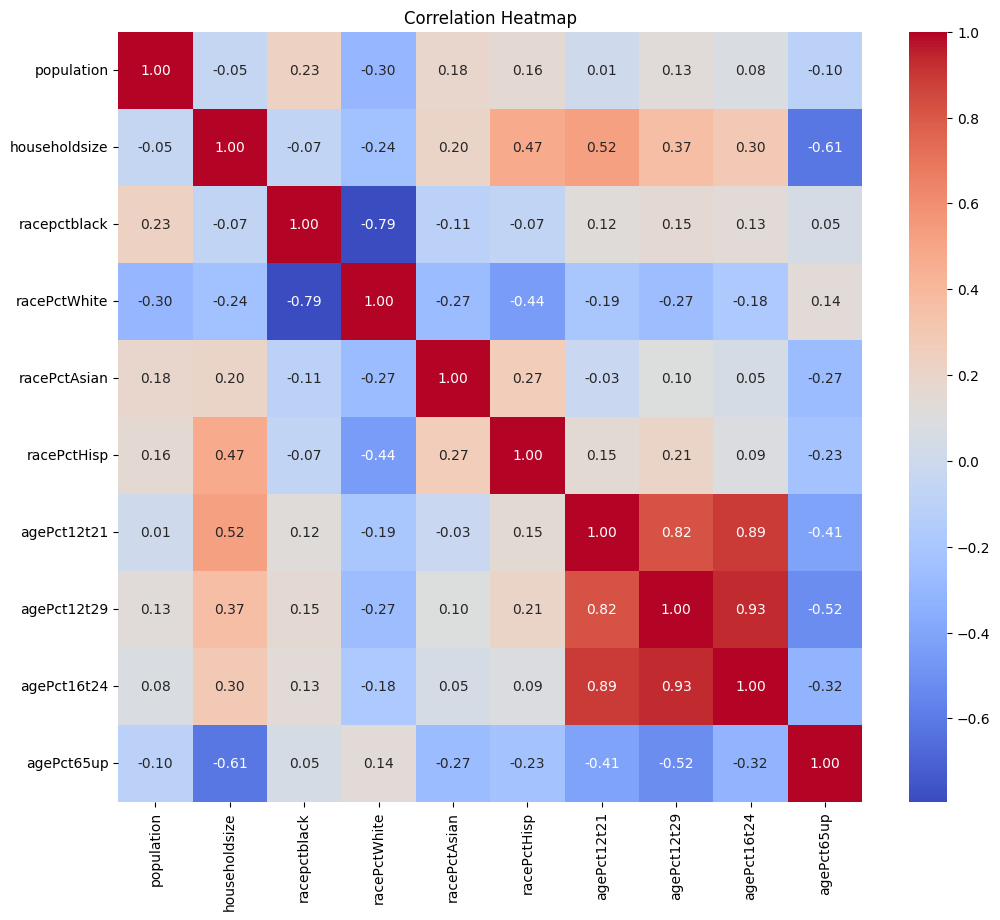

In [17]:
corr_data = pd.concat([X, y], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_data.corr(numeric_only=True).iloc[:10, :10],
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

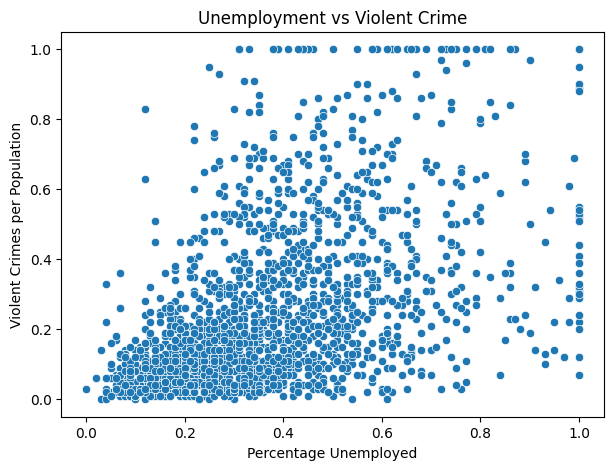

In [18]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X["PctUnemployed"], y=y)
plt.title("Unemployment vs Violent Crime")
plt.xlabel("Percentage Unemployed")
plt.ylabel("Violent Crimes per Population")
plt.show()

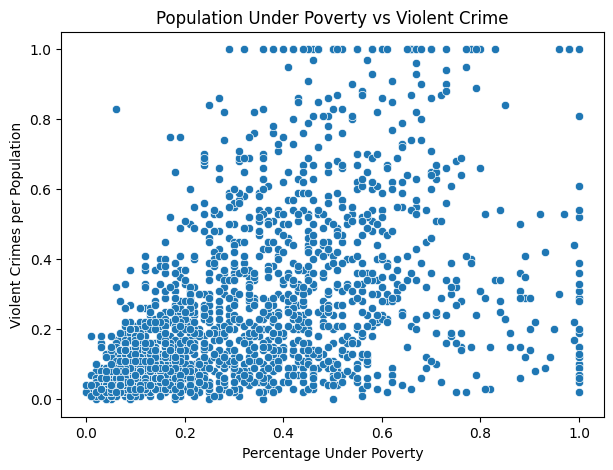

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X["PctPopUnderPov"], y=y)
plt.title("Population Under Poverty vs Violent Crime")
plt.xlabel("Percentage Under Poverty")
plt.ylabel("Violent Crimes per Population")
plt.show()

In [20]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 1. Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)


# 2. Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)


# 3. Lasso Regression
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)


# 4. ElasticNet Regression
elastic_model = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_scaled, y_train)

elastic_pred = elastic_model.predict(X_test_scaled)


# 5. Polynomial Regression
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)


print("All 5 regression models trained successfully.")
print("Polynomial features:", X_train_poly.shape)

All 5 regression models trained successfully.
Polynomial features: (1595, 7749)


In [22]:
results = []

predictions = {
    "Linear Regression": linear_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "ElasticNet Regression": elastic_pred,
    "Polynomial Regression": poly_pred
}

for name, pred in predictions.items():

    results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("R2", ascending=False)

,Model,R2,RMSE,MAE
2,Lasso Regression,0.635564,0.132117,0.091230
3,ElasticNet Regression,0.631498,0.132852,0.091868
1,Ridge Regression,0.622387,0.134484,0.094349
0,Linear Regression,0.621685,0.134609,0.094555
4,Polynomial Regression,-0.726984,0.287603,0.201295


In [23]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=3,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge parameters:")
print(ridge_grid.best_params_)

print("Best Ridge CV R2:")
print(ridge_grid.best_score_)

Best Ridge parameters:
{'alpha': 100}
Best Ridge CV R2:
0.6470473963288154


In [24]:
elastic = ElasticNet(
    alpha=0.001,
    max_iter=10000
)

elastic_params = {
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    cv=3,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

print("Best ElasticNet parameters:")
print(elastic_grid.best_params_)

print("Best ElasticNet CV R2:")
print(elastic_grid.best_score_)

Best ElasticNet parameters:
{'l1_ratio': 0.9}
Best ElasticNet CV R2:
0.6443163810507108


In [25]:
lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train.columns
)

zero_coefficients = (lasso_coefficients == 0).sum()
total_coefficients = len(lasso_coefficients)

print("Total features:", total_coefficients)
print("Features with zero coefficient:", zero_coefficients)
print(
    "Percentage of zero coefficients:",
    round(zero_coefficients / total_coefficients * 100, 2),
    "%"
)

Total features: 123
Features with zero coefficient: 50
Percentage of zero coefficients: 40.65 %


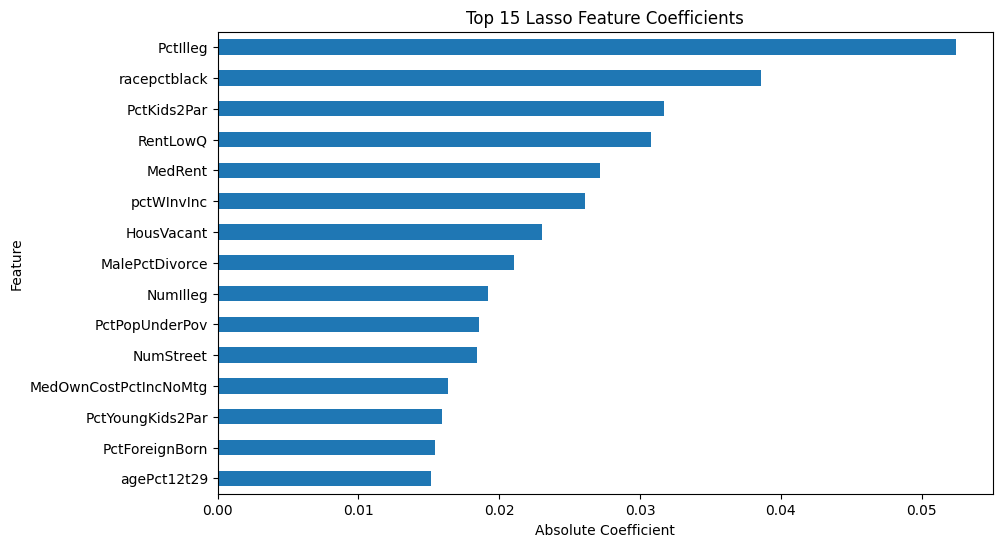

In [26]:
top_lasso = lasso_coefficients.abs().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
top_lasso.sort_values().plot(kind="barh")

plt.title("Top 15 Lasso Feature Coefficients")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

In [27]:
linear_coefficients = pd.Series(
    linear_model.coef_,
    index=X_train.columns
)

linear_coefficients.sort_values(
    key=abs,
    ascending=False
).head(15)

,0
PctRecImmig8,0.128946
PersPerOccupHous,0.123262
TotalPctDiv,-0.122131
PctPersOwnOccup,-0.092166
MalePctDivorce,0.089292
PctRecImmig10,-0.087783
whitePerCap,-0.076910
MedRent,0.072067
medFamInc,0.064751
RentLowQ,-0.054883


In [28]:
poly_results = []

for degree in [1, 2]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_p = poly.fit_transform(X_train_scaled)
    X_test_p = poly.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_p, y_train)

    pred = model.predict(X_test_p)

    poly_results.append({
        "Degree": degree,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

pd.DataFrame(poly_results)

,Degree,R2,RMSE,MAE
0,1,0.621685,0.134609,0.094555
1,2,-0.726984,0.287603,0.201295


In [29]:
# Final Polynomial Regression using the better degree

best_degree = 1

poly_final = PolynomialFeatures(
    degree=best_degree,
    include_bias=False
)

X_train_poly = poly_final.fit_transform(X_train_scaled)
X_test_poly = poly_final.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

print("Selected polynomial degree:", best_degree)
print("R2:", r2_score(y_test, poly_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))
print("MAE:", mean_absolute_error(y_test, poly_pred))

Selected polynomial degree: 1
R2: 0.6216851044922316
RMSE: 0.1346093402348001
MAE: 0.09455488261109622


In [30]:
# Final results for all 5 regression models

final_predictions = {
    "Linear Regression": linear_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "ElasticNet Regression": elastic_pred,
    "Polynomial Regression": poly_pred
}

final_results = []

for name, pred in final_predictions.items():
    final_results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values("R2", ascending=False)

,Model,R2,RMSE,MAE
2,Lasso Regression,0.635564,0.132117,0.091230
3,ElasticNet Regression,0.631498,0.132852,0.091868
1,Ridge Regression,0.622387,0.134484,0.094349
0,Linear Regression,0.621685,0.134609,0.094555
4,Polynomial Regression,0.621685,0.134609,0.094555


In [31]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=3,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)

Best Ridge parameters: {'alpha': 100}
Best Ridge CV R2: 0.6470473963288154


In [32]:
elastic = ElasticNet(
    alpha=0.001,
    max_iter=10000
)

elastic_params = {
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    cv=3,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

print("Best ElasticNet parameters:", elastic_grid.best_params_)
print("Best ElasticNet CV R2:", elastic_grid.best_score_)

Best ElasticNet parameters: {'l1_ratio': 0.9}
Best ElasticNet CV R2: 0.6443163810507108


In [33]:
from sklearn.model_selection import cross_val_score

# Best two models from our initial test results
best_lasso = lasso_model
best_elastic = elastic_grid.best_estimator_

# 5-fold CV
lasso_cv = cross_val_score(
    best_lasso,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

elastic_cv = cross_val_score(
    best_elastic,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Lasso 5-Fold CV R2:")
print(lasso_cv)
print("Mean:", lasso_cv.mean())

print("\nElasticNet 5-Fold CV R2:")
print(elastic_cv)
print("Mean:", elastic_cv.mean())

Lasso 5-Fold CV R2:
[0.66604907 0.64267142 0.64574818 0.66841488 0.61295042]
Mean: 0.647166796432719

ElasticNet 5-Fold CV R2:
[0.66553795 0.6427686  0.64657279 0.66807579 0.6118411 ]
Mean: 0.6469592449958843


In [34]:
# Lasso Feature Sparsity

lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train.columns
)

zero_coefficients = (lasso_coefficients == 0).sum()
total_coefficients = len(lasso_coefficients)

print("Total features:", total_coefficients)
print("Features with zero coefficient:", zero_coefficients)
print(
    "Percentage of zero coefficients:",
    round(zero_coefficients / total_coefficients * 100, 2),
    "%"
)


Total features: 123
Features with zero coefficient: 50
Percentage of zero coefficients: 40.65 %


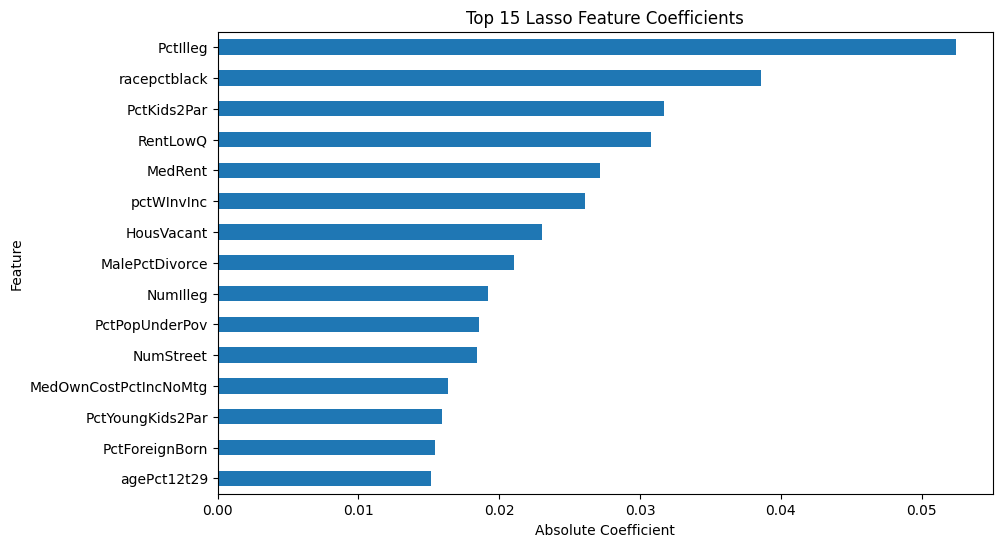

In [35]:
# Top Lasso coefficients

top_lasso = lasso_coefficients.abs().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
top_lasso.sort_values().plot(kind="barh")

plt.title("Top 15 Lasso Feature Coefficients")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

In [36]:
# Linear Regression coefficients

linear_coefficients = pd.Series(
    linear_model.coef_,
    index=X_train.columns
)

print("Top 15 Linear Regression coefficients:")
print(
    linear_coefficients
    .sort_values(key=abs, ascending=False)
    .head(15)
)


Top 15 Linear Regression coefficients:
PctRecImmig8           0.128946
PersPerOccupHous       0.123262
TotalPctDiv           -0.122131
PctPersOwnOccup       -0.092166
MalePctDivorce         0.089292
PctRecImmig10         -0.087783
whitePerCap           -0.076910
MedRent                0.072067
medFamInc              0.064751
RentLowQ              -0.054883
PctLargHouseOccup     -0.054194
PctHousOwnOcc          0.052224
numbUrban             -0.046391
PctNotSpeakEnglWell   -0.044626
LemasSwornFT          -0.044088
dtype: float64


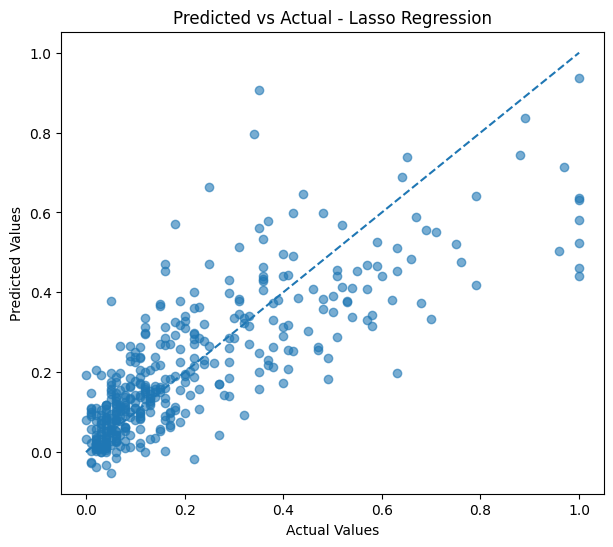

In [37]:
# Predicted vs Actual - Lasso

best_model = lasso_model
best_pred = lasso_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))

plt.scatter(y_test, best_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Predicted vs Actual - Lasso Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

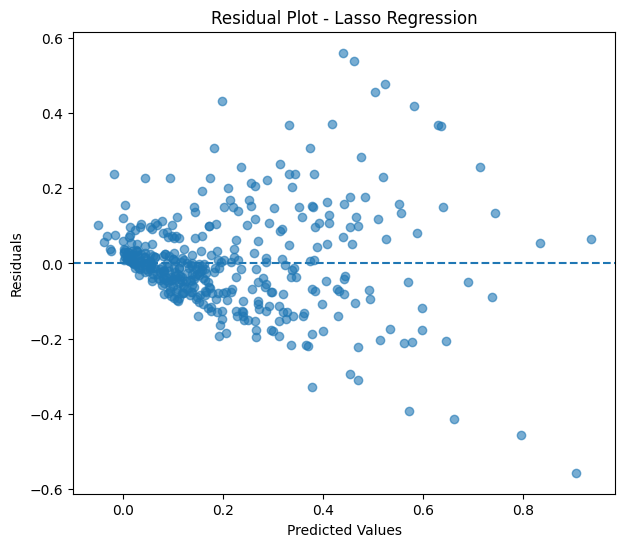

In [38]:
# Residual Plot - Lasso

residuals = y_test - best_pred

plt.figure(figsize=(7, 6))

plt.scatter(best_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Lasso Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

# REGRESSION MODELS 6–10

In [39]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 6. Decision Tree Regressor

Decision Tree Regressor is a supervised learning algorithm that predicts a
continuous target variable by recursively splitting the data into smaller
groups based on feature values.

For this project, Decision Tree Regressor is used to predict
ViolentCrimesPerPop.

The model is evaluated using R², RMSE, and MAE.

The max_depth hyperparameter is tuned using GridSearchCV with 5-fold
cross-validation to control the complexity of the tree and reduce
overfitting.

In [41]:
# Decision Tree Regressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Evaluation
dt_r2 = r2_score(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae = mean_absolute_error(y_test, dt_pred)

print("Decision Tree Regressor")
print("----------------------")
print("R²   :", dt_r2)
print("RMSE :", dt_rmse)
print("MAE  :", dt_mae)

Decision Tree Regressor
----------------------
R²   : 0.21003759083152596
RMSE : 0.19451436861835553
MAE  : 0.1237844611528822


In [42]:
# Hyperparameter tuning for Decision Tree

dt_param_grid = {
    "max_depth": [3, 5, 10, 15, 20, None]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best max_depth:", dt_grid.best_params_["max_depth"])
print("Best CV R²:", dt_grid.best_score_)

Best max_depth: 3
Best CV R²: 0.5419123604051036


In [43]:
# Best Decision Tree model

dt_best = dt_grid.best_estimator_

dt_best_pred = dt_best.predict(X_test)

dt_best_r2 = r2_score(y_test, dt_best_pred)
dt_best_rmse = np.sqrt(mean_squared_error(y_test, dt_best_pred))
dt_best_mae = mean_absolute_error(y_test, dt_best_pred)

print("Tuned Decision Tree Regressor")
print("-----------------------------")
print("Best Parameters:", dt_grid.best_params_)
print("R²   :", dt_best_r2)
print("RMSE :", dt_best_rmse)
print("MAE  :", dt_best_mae)

Tuned Decision Tree Regressor
-----------------------------
Best Parameters: {'max_depth': 3}
R²   : 0.5417398954152378
RMSE : 0.1481509702200737
MAE  : 0.1025736203101655


In [44]:
# Feature importance

dt_importance = pd.Series(
    dt_best.feature_importances_,
    index=X_train.columns
)

dt_importance = dt_importance.sort_values(
    ascending=False
)

print("Top 15 Important Features:")
print(dt_importance.head(15))

Top 15 Important Features:
PctIlleg         0.680735
PctKids2Par      0.106852
PctFam2Par       0.094059
NumStreet        0.038907
racePctWhite     0.038061
NumIlleg         0.034678
racePctHisp      0.006707
racepctblack     0.000000
householdsize    0.000000
racePctAsian     0.000000
agePct12t21      0.000000
pctUrban         0.000000
medIncome        0.000000
pctWWage         0.000000
pctWFarmSelf     0.000000
dtype: float64


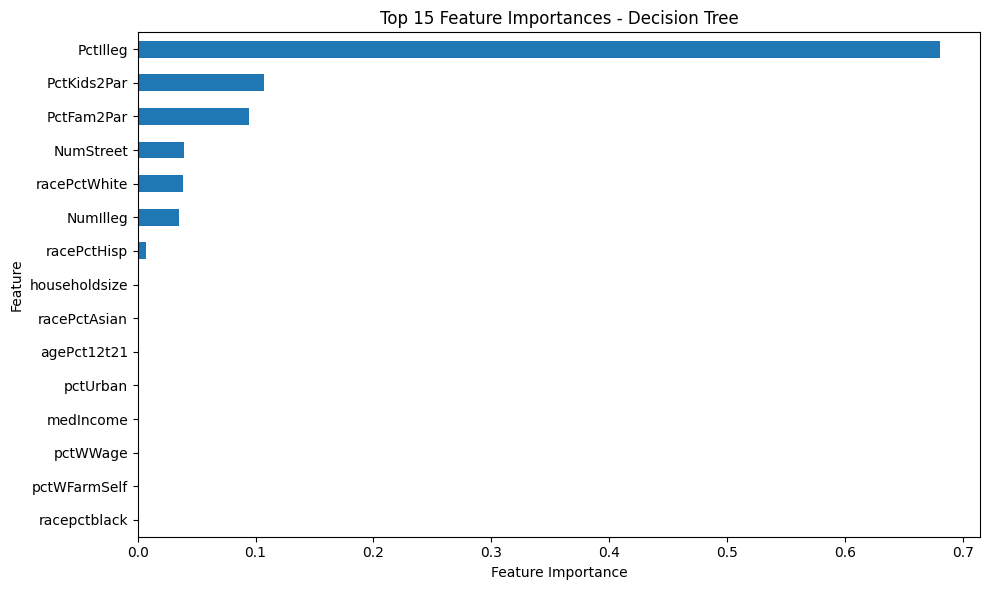

In [45]:
plt.figure(figsize=(10, 6))

dt_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances - Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 7.Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines
multiple decision trees.

Each tree is trained using different samples of the training data and
feature subsets. The predictions from the individual trees are combined
to produce the final prediction.

The n_estimators parameter is tuned using GridSearchCV with 5-fold
cross-validation.

In [48]:
# 7. Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Regressor")
print("----------------------")
print("R²   :", rf_r2)
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)

Random Forest Regressor
----------------------
R²   : 0.6150642648872582
RMSE : 0.13578212156370534
MAE  : 0.09273258145363407


In [50]:
rf_param_grid = {
    "n_estimators": [50, 100]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV R²:", rf_grid.best_score_)

Best Parameters: {'n_estimators': 100}
Best CV R²: 0.6446283670694157


In [51]:
# Best Random Forest model

rf_best = rf_grid.best_estimator_

rf_best_pred = rf_best.predict(X_test)

rf_best_r2 = r2_score(y_test, rf_best_pred)
rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_pred))
rf_best_mae = mean_absolute_error(y_test, rf_best_pred)

print("Tuned Random Forest Regressor")
print("-----------------------------")
print("Best Parameters:", rf_grid.best_params_)
print("R²   :", rf_best_r2)
print("RMSE :", rf_best_rmse)
print("MAE  :", rf_best_mae)

Tuned Random Forest Regressor
-----------------------------
Best Parameters: {'n_estimators': 100}
R²   : 0.6150642648872582
RMSE : 0.13578212156370534
MAE  : 0.09273258145363407


In [52]:
# Random Forest Feature Importance

rf_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train.columns
)

rf_importance = rf_importance.sort_values(
    ascending=False
)

print("Top 15 Important Features:")
print(rf_importance.head(15))

Top 15 Important Features:
PctIlleg            0.327073
PctKids2Par         0.211986
racePctWhite        0.028544
PctFam2Par          0.021582
FemalePctDiv        0.013540
NumIlleg            0.012781
PctPersDenseHous    0.011294
AsianPerCap         0.010514
MalePctDivorce      0.010476
NumStreet           0.010112
TotalPctDiv         0.009630
PctHousLess3BR      0.009386
HousVacant          0.009362
PctUsePubTrans      0.008631
pctWInvInc          0.008057
dtype: float64


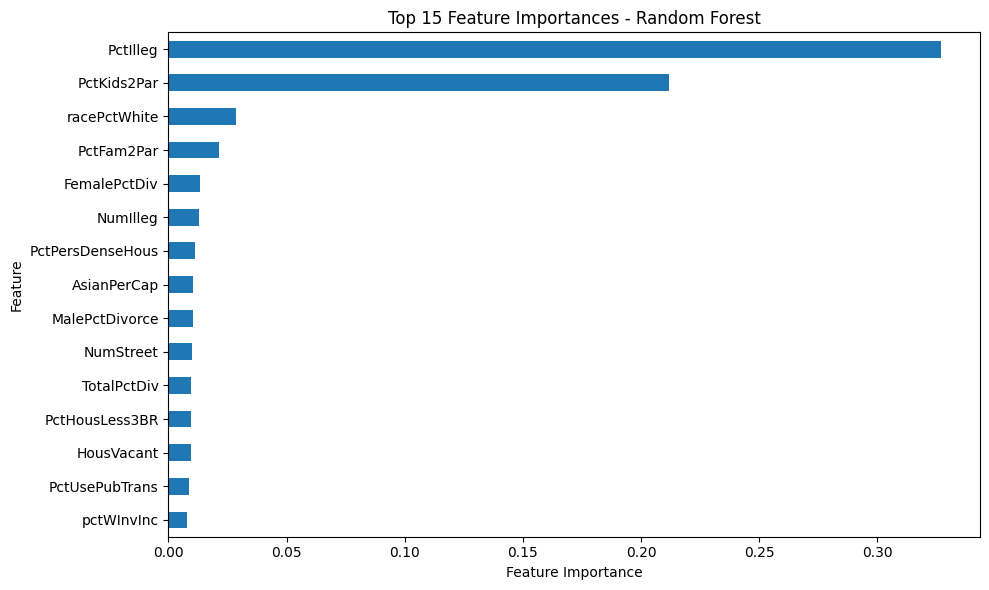

In [53]:
plt.figure(figsize=(10, 6))

rf_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 8. Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble learning algorithm that builds
decision trees sequentially.

Each new tree attempts to correct the errors made by the previous trees.
The final prediction is obtained by combining the predictions of all
trees.

The n_estimators and learning_rate parameters are tuned using GridSearchCV
with 5-fold cross-validation.

In [54]:
# 8. Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("---------------------------")
print("R²   :", gb_r2)
print("RMSE :", gb_rmse)
print("MAE  :", gb_mae)

Gradient Boosting Regressor
---------------------------
R²   : 0.5918531775585449
RMSE : 0.13981593936309988
MAE  : 0.09339847062987859


In [55]:
# Hyperparameter tuning for Gradient Boosting

gb_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV R²:", gb_grid.best_score_)

Best Parameters: {'learning_rate': 0.05, 'n_estimators': 150}
Best CV R²: 0.6538736836365492


In [57]:
# Best Gradient Boosting model

gb_best = gb_grid.best_estimator_

gb_best_pred = gb_best.predict(X_test)

gb_best_r2 = r2_score(y_test, gb_best_pred)
gb_best_rmse = np.sqrt(mean_squared_error(y_test, gb_best_pred))
gb_best_mae = mean_absolute_error(y_test, gb_best_pred)

print("Tuned Gradient Boosting Regressor")
print("---------------------------------")
print("Best Parameters:", gb_grid.best_params_)
print("R²   :", gb_best_r2)
print("RMSE :", gb_best_rmse)
print("MAE  :", gb_best_mae)

Tuned Gradient Boosting Regressor
---------------------------------
Best Parameters: {'learning_rate': 0.05, 'n_estimators': 150}
R²   : 0.5983993925079741
RMSE : 0.138690162036486
MAE  : 0.09249912076692926


In [58]:
# Gradient Boosting Feature Importance

gb_importance = pd.Series(
    gb_best.feature_importances_,
    index=X_train.columns
)

gb_importance = gb_importance.sort_values(
    ascending=False
)

print("Top 15 Important Features:")
print(gb_importance.head(15))

Top 15 Important Features:
PctKids2Par         0.308466
PctIlleg            0.240413
NumIlleg            0.072177
racePctWhite        0.050594
PctFam2Par          0.028114
NumStreet           0.022576
pctWInvInc          0.020203
racepctblack        0.019539
FemalePctDiv        0.018793
MalePctDivorce      0.018732
TotalPctDiv         0.014679
HousVacant          0.010233
PctPersDenseHous    0.009317
PctHousLess3BR      0.008850
racePctHisp         0.007510
dtype: float64


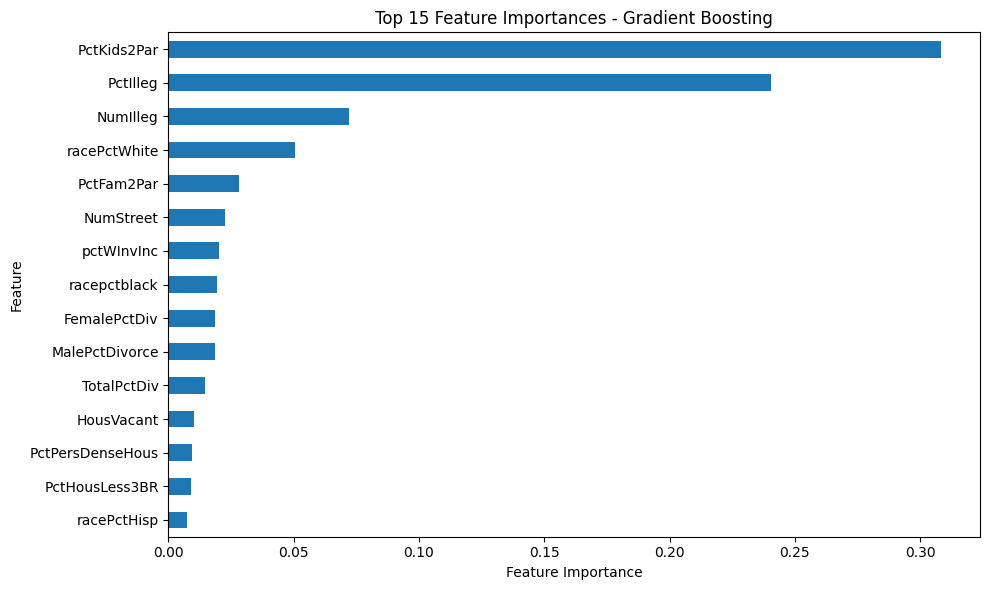

In [59]:
plt.figure(figsize=(10, 6))

gb_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 9. Support Vector Regressor

Support Vector Regressor (SVR) is a supervised learning algorithm that
predicts continuous values by finding a function that fits the training
data while allowing a specified margin of error.

SVR is sensitive to feature scales. Therefore, the standardized training
and testing data created earlier using StandardScaler are used.

The C and kernel parameters are tuned using GridSearchCV with 5-fold
cross-validation.

In [60]:
# 9. Support Vector Regressor

svr_model = SVR(
    C=1.0,
    kernel="rbf"
)

svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)

svr_r2 = r2_score(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_mae = mean_absolute_error(y_test, svr_pred)

print("Support Vector Regressor")
print("------------------------")
print("R²   :", svr_r2)
print("RMSE :", svr_rmse)
print("MAE  :", svr_mae)

Support Vector Regressor
------------------------
R²   : 0.5684196460606066
RMSE : 0.1437736533348745
MAE  : 0.1027654331845001


In [65]:
from sklearn.svm import SVR

svr_model = SVR(
    C=10,
    kernel="linear"
)

svr_model.fit(X_train_scaled, y_train)

y_pred = svr_model.predict(X_test_scaled)

In [68]:
# Best SVR model
svr_best = svr_model

svr_best_pred = svr_best.predict(X_test_scaled)

svr_best_r2 = r2_score(y_test, svr_best_pred)
svr_best_rmse = np.sqrt(mean_squared_error(y_test, svr_best_pred))
svr_best_mae = mean_absolute_error(y_test, svr_best_pred)

print("Support Vector Regressor")
print("Parameters: C=10, kernel=linear")
print("R²:", svr_best_r2)
print("RMSE:", svr_best_rmse)
print("MAE:", svr_best_mae)

Support Vector Regressor
Parameters: C=10, kernel=linear
R²: 0.6114707563257894
RMSE: 0.13641443586671348
MAE: 0.09526605662679703


# 10. K-Nearest Neighbors Regressor

K-Nearest Neighbors (KNN) Regressor predicts the target value of a new
observation using the target values of its nearest training observations.

KNN is a distance-based algorithm, so feature scaling is important.
Therefore, the standardized training and testing data are used.

The n_neighbors parameter represents the number of neighboring observations
used for prediction and is tuned using GridSearchCV.

In [69]:
# 10. K-Nearest Neighbors Regressor

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_r2 = r2_score(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_mae = mean_absolute_error(y_test, knn_pred)

print("K-Nearest Neighbors Regressor")
print("-----------------------------")
print("R²   :", knn_r2)
print("RMSE :", knn_rmse)
print("MAE  :", knn_mae)

K-Nearest Neighbors Regressor
-----------------------------
R²   : 0.5625354422556765
RMSE : 0.1447504463873024
MAE  : 0.09754887218045113


In [70]:
# Hyperparameter tuning for KNN

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV R²:", knn_grid.best_score_)

Best Parameters: {'n_neighbors': 9}
Best CV R²: 0.5972649147842475


In [71]:
# Best KNN model

knn_best = knn_grid.best_estimator_

knn_best_pred = knn_best.predict(X_test_scaled)

knn_best_r2 = r2_score(y_test, knn_best_pred)
knn_best_rmse = np.sqrt(mean_squared_error(y_test, knn_best_pred))
knn_best_mae = mean_absolute_error(y_test, knn_best_pred)

print("Tuned K-Nearest Neighbors Regressor")
print("-----------------------------------")
print("Best Parameters:", knn_grid.best_params_)
print("R²   :", knn_best_r2)
print("RMSE :", knn_best_rmse)
print("MAE  :", knn_best_mae)

Tuned K-Nearest Neighbors Regressor
-----------------------------------
Best Parameters: {'n_neighbors': 9}
R²   : 0.5887500724731055
RMSE : 0.14034643720351053
MAE  : 0.09596491228070175


# Compare all 10 regression models

In [72]:
# ============================================================
# COMPARISON OF ALL 10 REGRESSION MODELS
# ============================================================

all_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression",
        "Polynomial Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "Support Vector Regressor",
        "K-Nearest Neighbors Regressor"
    ],

    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred),
        r2_score(y_test, poly_pred),
        dt_best_r2,
        rf_best_r2,
        gb_best_r2,
        svr_best_r2,
        knn_best_r2
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, elastic_pred)),
        np.sqrt(mean_squared_error(y_test, poly_pred)),
        dt_best_rmse,
        rf_best_rmse,
        gb_best_rmse,
        svr_best_rmse,
        knn_best_rmse
    ],

    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred),
        mean_absolute_error(y_test, poly_pred),
        dt_best_mae,
        rf_best_mae,
        gb_best_mae,
        svr_best_mae,
        knn_best_mae
    ]
})

all_results

,Model,R2,RMSE,MAE
0,Linear Regression,0.621685,0.134609,0.094555
1,Ridge Regression,0.622387,0.134484,0.094349
2,Lasso Regression,0.635564,0.132117,0.091230
3,ElasticNet Regression,0.631498,0.132852,0.091868
4,Polynomial Regression,0.621685,0.134609,0.094555
5,Decision Tree Regressor,0.541740,0.148151,0.102574
6,Random Forest Regressor,0.615064,0.135782,0.092733
7,Gradient Boosting Regressor,0.598399,0.138690,0.092499
8,Support Vector Regressor,0.611471,0.136414,0.095266
9,K-Nearest Neighbors Regressor,0.588750,0.140346,0.095965


In [73]:
# Sort by R²

all_results_sorted = all_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

all_results_sorted

,Model,R2,RMSE,MAE
0,Lasso Regression,0.635564,0.132117,0.091230
1,ElasticNet Regression,0.631498,0.132852,0.091868
2,Ridge Regression,0.622387,0.134484,0.094349
3,Linear Regression,0.621685,0.134609,0.094555
4,Polynomial Regression,0.621685,0.134609,0.094555
5,Random Forest Regressor,0.615064,0.135782,0.092733
6,Support Vector Regressor,0.611471,0.136414,0.095266
7,Gradient Boosting Regressor,0.598399,0.138690,0.092499
8,K-Nearest Neighbors Regressor,0.588750,0.140346,0.095965
9,Decision Tree Regressor,0.541740,0.148151,0.102574


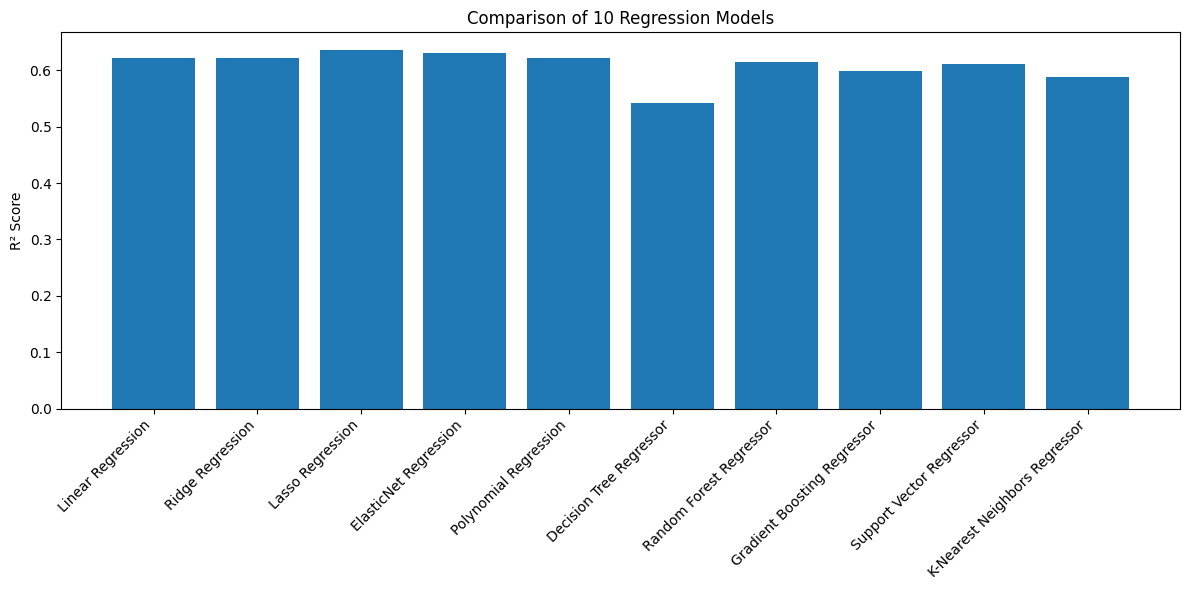

In [74]:
plt.figure(figsize=(12, 6))

plt.bar(
    all_results["Model"],
    all_results["R2"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("R² Score")
plt.title("Comparison of 10 Regression Models")

plt.tight_layout()
plt.show()

# 5-Fold Cross-Validation

In [75]:
# ============================================================
# 5-FOLD CROSS-VALIDATION FOR MODELS 6–10
# ============================================================

dt_cv = cross_val_score(
    dt_best,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

rf_cv = cross_val_score(
    rf_best,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_cv = cross_val_score(
    gb_best,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_cv = cross_val_score(
    svr_best,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

knn_cv = cross_val_score(
    knn_best,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

cv_results_6_10 = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR",
        "KNN"
    ],

    "Mean CV R2": [
        dt_cv.mean(),
        rf_cv.mean(),
        gb_cv.mean(),
        svr_cv.mean(),
        knn_cv.mean()
    ],

    "CV R2 Std": [
        dt_cv.std(),
        rf_cv.std(),
        gb_cv.std(),
        svr_cv.std(),
        knn_cv.std()
    ]
})

cv_results_6_10

,Model,Mean CV R2,CV R2 Std
0,Decision Tree,0.541912,0.023547
1,Random Forest,0.644304,0.018748
2,Gradient Boosting,0.653874,0.020593
3,SVR,0.620559,0.036463
4,KNN,0.597265,0.021416


# Model Diagnostic — Random Forest

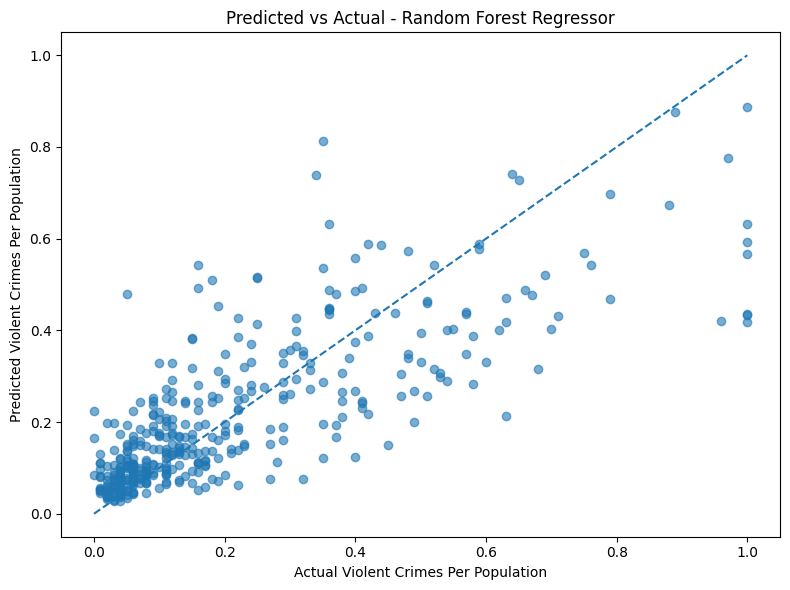

In [76]:
# Predicted vs Actual Plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_best_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Predicted vs Actual - Random Forest Regressor")
plt.xlabel("Actual Violent Crimes Per Population")
plt.ylabel("Predicted Violent Crimes Per Population")

plt.tight_layout()
plt.show()

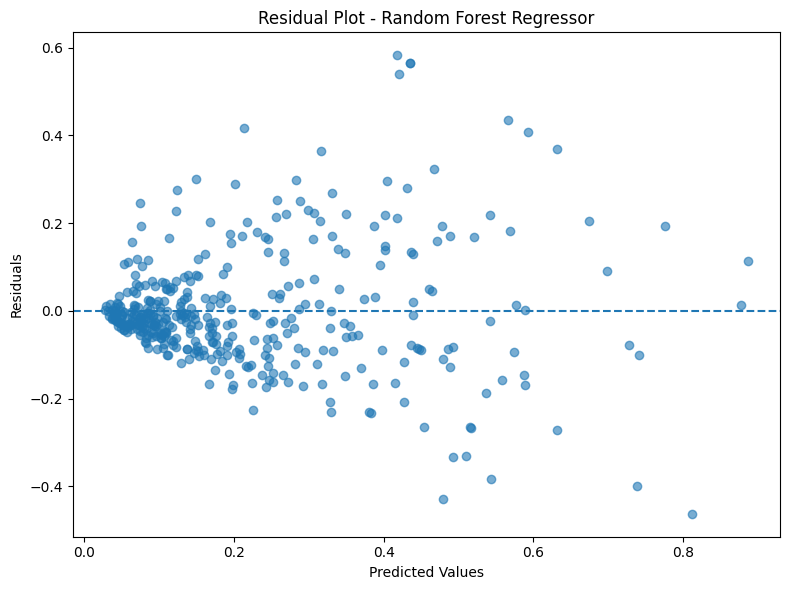

In [77]:
# Residual Plot

rf_residuals = y_test - rf_best_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    rf_best_pred,
    rf_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Random Forest Regressor")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [78]:
print("================================================")
print("FINAL REGRESSION RESULTS - MODELS 6 TO 10")
print("================================================")

print("\nDecision Tree")
print("R²   :", round(dt_best_r2, 6))
print("RMSE :", round(dt_best_rmse, 6))
print("MAE  :", round(dt_best_mae, 6))

print("\nRandom Forest")
print("R²   :", round(rf_best_r2, 6))
print("RMSE :", round(rf_best_rmse, 6))
print("MAE  :", round(rf_best_mae, 6))

print("\nGradient Boosting")
print("R²   :", round(gb_best_r2, 6))
print("RMSE :", round(gb_best_rmse, 6))
print("MAE  :", round(gb_best_mae, 6))

print("\nSupport Vector Regressor")
print("R²   :", round(svr_best_r2, 6))
print("RMSE :", round(svr_best_rmse, 6))
print("MAE  :", round(svr_best_mae, 6))

print("\nK-Nearest Neighbors")
print("R²   :", round(knn_best_r2, 6))
print("RMSE :", round(knn_best_rmse, 6))
print("MAE  :", round(knn_best_mae, 6))

FINAL REGRESSION RESULTS - MODELS 6 TO 10

Decision Tree
R²   : 0.54174
RMSE : 0.148151
MAE  : 0.102574

Random Forest
R²   : 0.615064
RMSE : 0.135782
MAE  : 0.092733

Gradient Boosting
R²   : 0.598399
RMSE : 0.13869
MAE  : 0.092499

Support Vector Regressor
R²   : 0.611471
RMSE : 0.136414
MAE  : 0.095266

K-Nearest Neighbors
R²   : 0.58875
RMSE : 0.140346
MAE  : 0.095965
